In [1]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from geometry_msgs.msg import Vector3
import rclpy
from rclpy.node import Node
import numpy as np
import time

In [2]:
class visualizer_node(Node):
    def __init__(self):
        super().__init__('visualizer_node')
        # Subscriber
        self.subscription = self.create_subscription(Vector3,'/euler_angles',self.status_callback,10)
        self.setpoint, self.y, self.x = [], [], []
        self.start_time = time.time()
        self.fig = plt.figure()
        self.ax = self.fig.add_subplot(1, 1, 1)
        # job = threading.Thread(target=self.ask_for_angle)
        # job.start()

    def status_callback(self, msg: Vector3) -> None:
        current_time = time.time()
        # self.get_logger().info(f"Received status: {msg.data}")
        current_pt = msg.z * 180 / np.pi
        self.x += [current_time - self.start_time]
        self.y += [current_pt]
        self.setpoint += [0]
        self.x = self.x[-500:]
        self.y = self.y[-500:]
        self.setpoint = self.setpoint[-500:]
        # print(f"angle: {angle}, target: {self.target}")
        self.ax.cla()
        # only show the last 100 points
        self.ax.plot(self.x, self.y, label="angle")
        self.ax.plot(self.x, self.setpoint, label="setpoint")
        
        self.ax.set_xlabel("time (s)")
        self.ax.set_ylabel("point") 
        # set the max to 360 and min to 0
        # self.ax.set_ylim([0, 360])
        plt.grid()

        display(self.fig)
        clear_output(wait = True)

In [3]:
def main():
    rclpy.init(args=None)
    comm = visualizer_node()
    rclpy.spin(comm)
    comm.destroy_node()
    rclpy.shutdown()

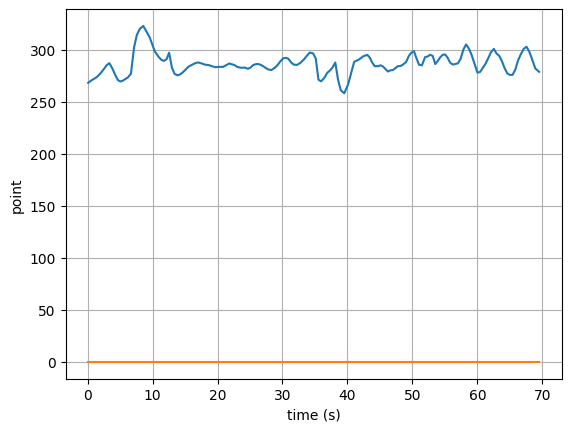

In [ ]:
main()